In [26]:
import pickle
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- 1. Chemins adaptés à votre architecture Git ---
dossier_images = "abstrait-v4" 
fichier_pkl_collegue = "features.pkl"
fichier_npy_cnn = "cnn_features_pca.npy"

# --- 2. Chargement et décryptage du PKL du collègue ---
print("Lecture du fichier PKL...")
with open(fichier_pkl_collegue, "rb") as f:
    data_collegue = pickle.load(f)

# Détection de la structure (Tuple Noms/Matrice ou DataFrame)
if isinstance(data_collegue, tuple):
    if isinstance(data_collegue[0], (list, np.ndarray)) and isinstance(data_collegue[0][0], str):
        noms_collegue = data_collegue[0]
        X_collegue_brut = np.array(data_collegue[1])
    else:
        X_collegue_brut = np.array(data_collegue[0])
        noms_collegue = data_collegue[1]
else:
    # Si le collègue a utilisé Pandas
    import pandas as pd
    df_collegue = pd.DataFrame(data_collegue)
    noms_collegue = df_collegue.index.tolist() if isinstance(df_collegue.index[0], str) else df_collegue.iloc[:, 0].tolist()
    X_collegue_brut = df_collegue.select_dtypes(include=[np.number]).values

print(f"Features classiques extraites : {X_collegue_brut.shape}")

# Dictionnaire pour l'alignement
dict_features_collegue = {nom: vecteur for nom, vecteur in zip(noms_collegue, X_collegue_brut)}

# --- 3. Récupération de l'ordre de VOS images (Dossier abstrait-v4) ---
image_extensions = (".jpg", ".jpeg", ".png")
image_names_cnn = [f for f in os.listdir(dossier_images) if f.lower().endswith(image_extensions)]

# --- 4. Alignement parfait des matrices ---
print("Alignement des deux matrices pour garantir l'ordre des œuvres...")
X_collegue_aligne = []

for nom in image_names_cnn:
    # Recherche souple du nom d'image dans les clés du collègue
    cles_possibles = [k for k in dict_features_collegue.keys() if nom in k]
    
    if cles_possibles:
        X_collegue_aligne.append(dict_features_collegue[cles_possibles[0]])
    else:
        raise ValueError(f"DANGER : L'image {nom} est introuvable dans le fichier features.pkl !")

X_collegue = np.array(X_collegue_aligne)
X_cnn = np.load(fichier_npy_cnn)

print(f"Ordre validé ! Dimensions : Collègue={X_collegue.shape}, CNN={X_cnn.shape}")

# --- 5. Équité dimensionnelle (Réduction du PKL) ---
n_comp_equilibre = X_cnn.shape[1] 
print(f"Réduction des features classiques à {n_comp_equilibre} composantes (PCA)...")

# Nettoyage et normalisation avant PCA
X_collegue_clean = np.nan_to_num(X_collegue, nan=np.nanmedian(X_collegue))
scaler_pre_pca = StandardScaler()
X_collegue_scaled = scaler_pre_pca.fit_transform(X_collegue_clean)

pca_collegue = PCA(n_components=n_comp_equilibre)
X_collegue_reduit = pca_collegue.fit_transform(X_collegue_scaled)

# --- 6. La Fusion Pondérée (Alpha Blending) ---
print("Concaténation et pondération globale de l'espace...")

# Définition des poids d'importance
POIDS_CNN = 0.85
POIDS_CLASSIQUE = 0.15

# On applique les poids en multipliant directement les matrices standardisées
X_collegue_pondere = X_collegue_final * POIDS_CLASSIQUE
X_cnn_pondere = X_cnn_final * POIDS_CNN

# Concaténation des blocs
X_fusion = np.hstack((X_collegue_pondere, X_cnn_pondere))

# ATTENTION : On ne refait surtout PAS de StandardScaler sur X_fusion ici !
# Sinon la standardisation ramènerait la variance de chaque colonne à 1,
# annulant instantanément notre pondération 85/15.
X_final = X_fusion

print(f"🎉 Matrice multimodale pondérée (CNN {POIDS_CNN*100}%) prête : {X_final.shape}")

Lecture du fichier PKL...
Features classiques extraites : (1700, 1922)
Alignement des deux matrices pour garantir l'ordre des œuvres...
Ordre validé ! Dimensions : Collègue=(1700, 1922), CNN=(1700, 50)
Réduction des features classiques à 50 composantes (PCA)...
Concaténation et pondération globale de l'espace...
🎉 Matrice multimodale pondérée (CNN 85.0%) prête : (1700, 100)


In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

# --- 1. Lancement du K-Means sur la matrice fusionnée ---
k_choisi = 15
print(f"Lancement du clustering sur l'espace multimodal (K={k_choisi})...")
kmeans_fusion = KMeans(n_clusters=k_choisi, random_state=42, n_init=10)

# Attention : on utilise bien la variable image_names_cnn créée à l'étape d'alignement
cluster_labels = kmeans_fusion.fit_predict(X_final)

# --- 2. Évaluation Mathématique ---
score_silhouette = silhouette_score(X_final, cluster_labels)
print(f"Score de Silhouette (Fusion) : {score_silhouette:.4f}")
print("-" * 40)

# --- 3. Préparation des résultats pour l'analyse sémantique ---
artistes = [nom.split('_')[0].capitalize() for nom in image_names_cnn]
df_results = pd.DataFrame({
    'Artiste': artistes,
    'Cluster': cluster_labels
})

print("Répartition globale des œuvres par cluster :")
print(df_results['Cluster'].value_counts().sort_index())

Lancement du clustering sur l'espace multimodal (K=15)...
Score de Silhouette (Fusion) : 0.0401
----------------------------------------
Répartition globale des œuvres par cluster :
Cluster
0      80
1      31
2     181
3     179
4      63
5      75
6     140
7      27
8     285
9     133
10     35
11    107
12    240
13     82
14     42
Name: count, dtype: int64


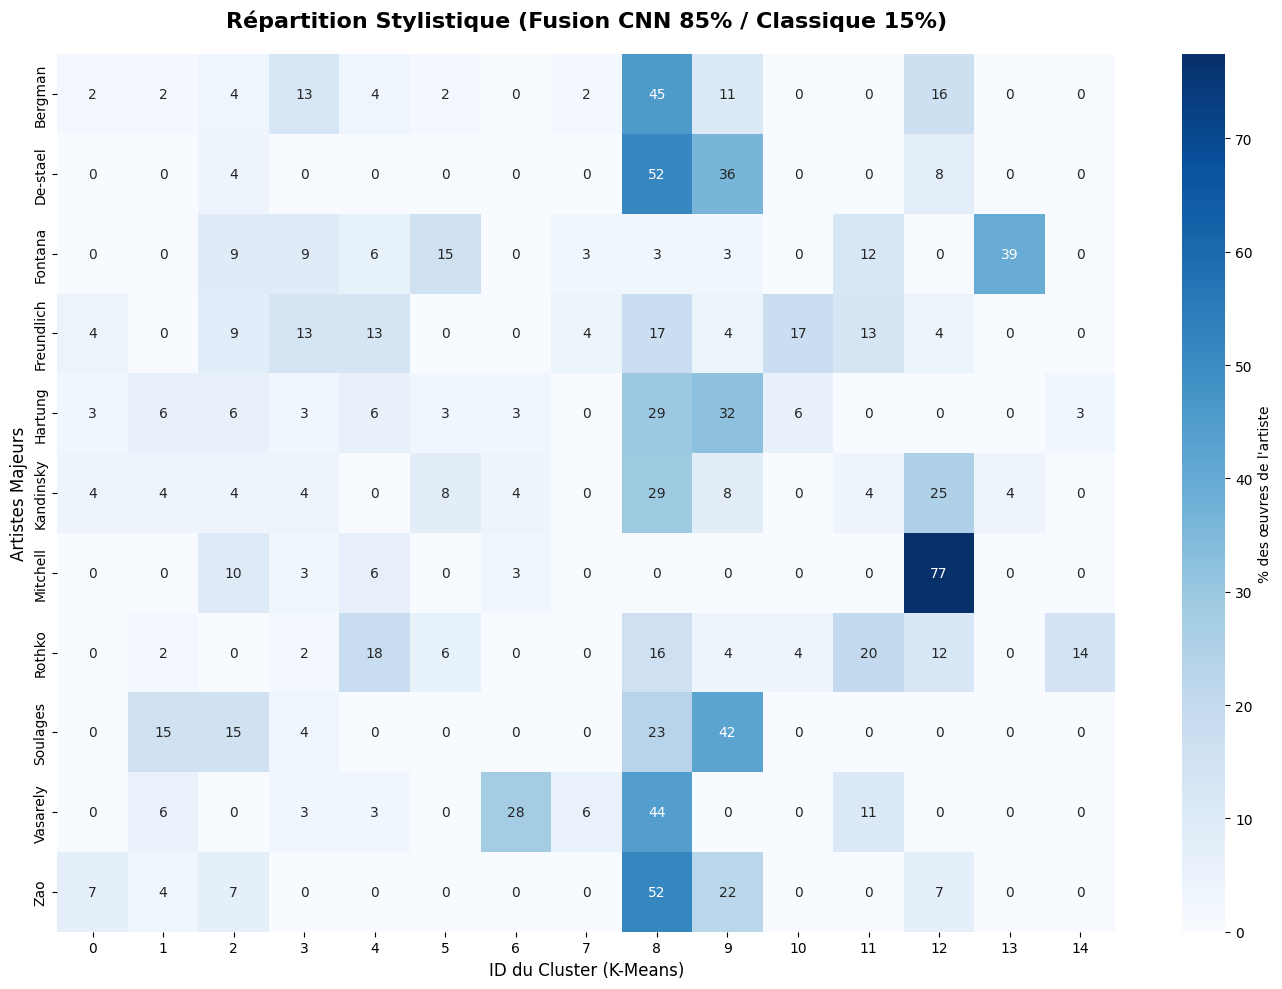

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Création du DataFrame avec la bonne liste d'images ---
artistes = [nom.split('_')[0].capitalize() for nom in image_names_cnn]
df_results = pd.DataFrame({
    'Artiste': artistes,
    'Cluster': cluster_labels
})

# --- 2. Filtrage des artistes majeurs ---
SEUIL_ARTISTES_MAJEURS = 20
comptage_artistes = df_results['Artiste'].value_counts()
artistes_majeurs = comptage_artistes[comptage_artistes >= SEUIL_ARTISTES_MAJEURS].index

df_majeurs = df_results[df_results['Artiste'].isin(artistes_majeurs)]

# --- 3. Calcul du tableau croisé en pourcentages ---
crosstab = pd.crosstab(df_majeurs['Artiste'], df_majeurs['Cluster'])
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

# --- 4. Affichage de la Heatmap ---
plt.figure(figsize=(14, 10))

sns.heatmap(crosstab_pct, annot=True, fmt=".0f", cmap="Blues", 
            cbar_kws={'label': "% des œuvres de l'artiste"})

plt.title("Répartition Stylistique (Fusion CNN 85% / Classique 15%)", 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel("ID du Cluster (K-Means)", fontsize=12)
plt.ylabel("Artistes Majeurs", fontsize=12)

plt.tight_layout()
plt.show()

Préparation de la grille des plus proches voisins (Espace Multimodal)...


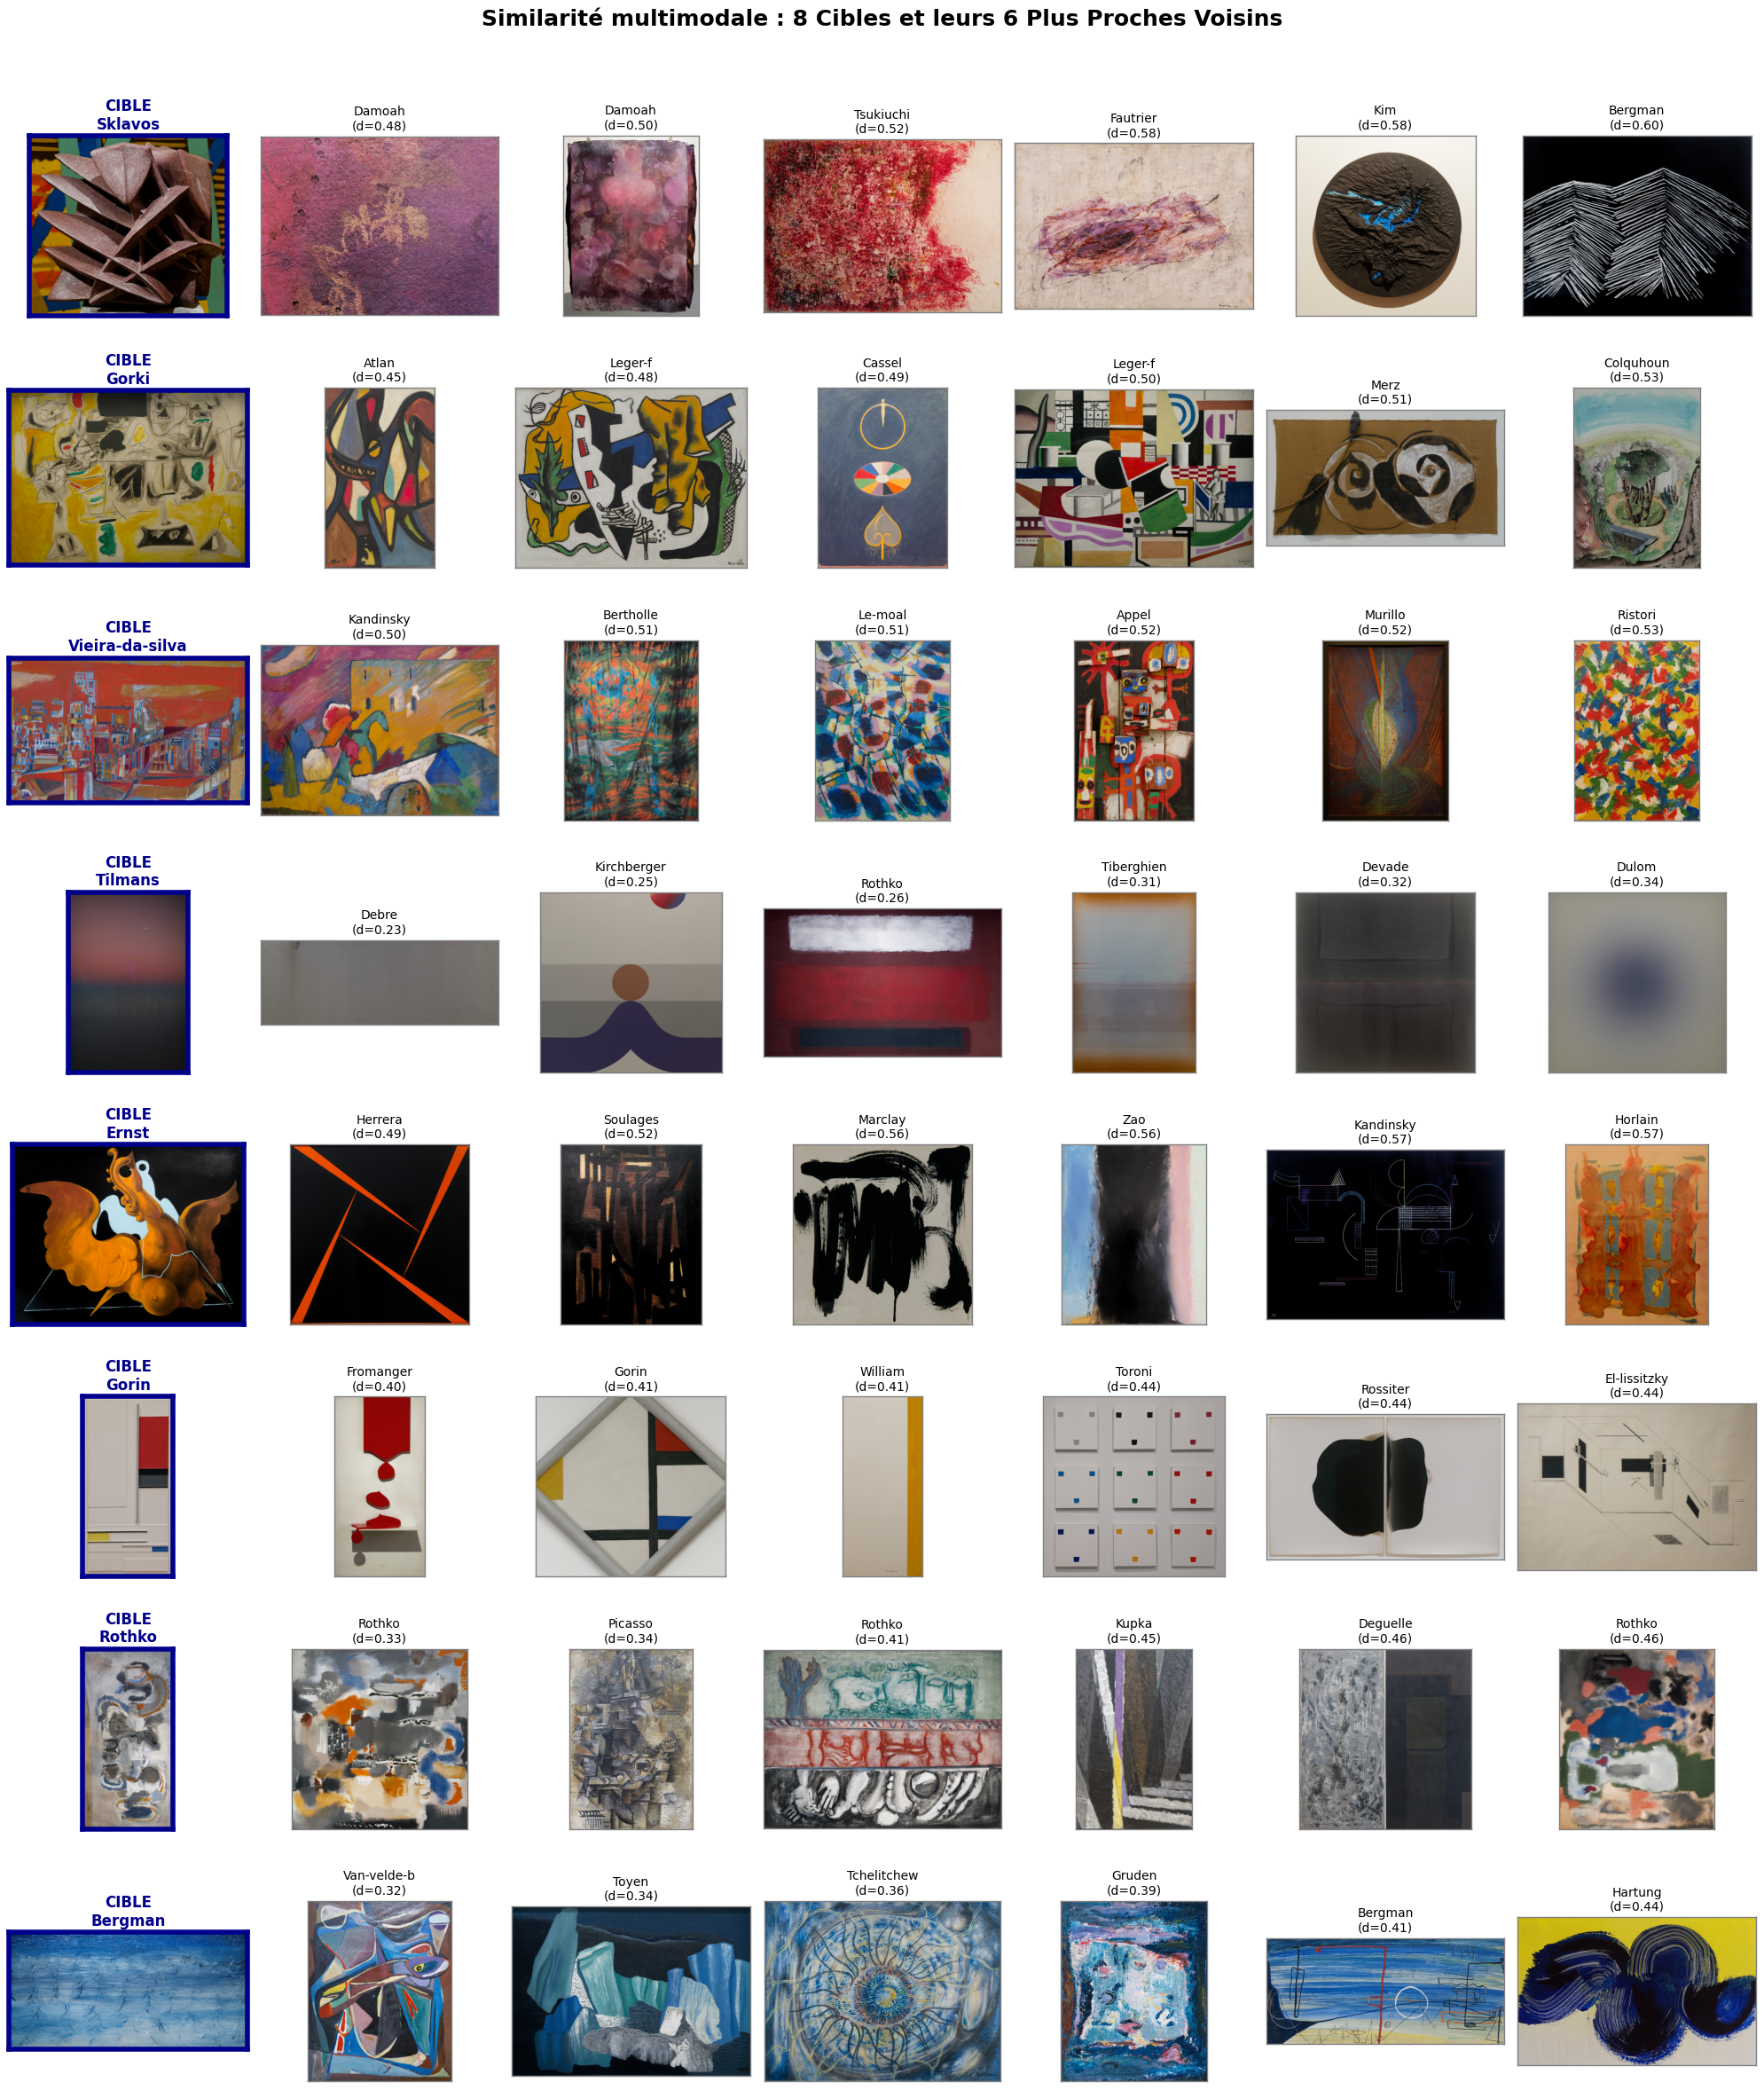

In [29]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
from sklearn.neighbors import NearestNeighbors

print("Préparation de la grille des plus proches voisins (Espace Multimodal)...")

# --- Paramètres ---
DATASET_DIR = "abstrait-v4"
NUM_TARGETS = 8     # Nombre de lignes (cibles au hasard)
N_NEIGHBORS = 6     # Nombre de voisins à trouver
N_COLS = N_NEIGHBORS + 1 

# --- 1. Entraînement du modèle de recherche sur la matrice fusionnée ---
nn_model = NearestNeighbors(n_neighbors=N_COLS, metric='cosine')
nn_model.fit(X_final)

# --- 2. Sélection aléatoire ---
random_indices = random.sample(range(len(image_names_cnn)), NUM_TARGETS)

# --- 3. Affichage ---
fig, axes = plt.subplots(NUM_TARGETS, N_COLS, figsize=(20, 3 * NUM_TARGETS))
fig.suptitle(f"Similarité multimodale : {NUM_TARGETS} Cibles et leurs {N_NEIGHBORS} Plus Proches Voisins", 
             fontsize=18, fontweight='bold', y=0.98)

for row, idx in enumerate(random_indices):
    target_vector = X_final[idx].reshape(1, -1)
    distances, indices = nn_model.kneighbors(target_vector)
    
    for col in range(N_COLS):
        ax = axes[row, col]
        voisin_idx = indices[0][col]
        voisin_name = image_names_cnn[voisin_idx]
        voisin_artiste = voisin_name.split('_')[0].capitalize()
        img_path = os.path.join(DATASET_DIR, voisin_name)
        
        try:
            img = mpimg.imread(img_path)
            ax.imshow(img)
            
            # Mise en forme : Cible (Bleu) vs Voisins (Gris)
            if col == 0:
                ax.set_title(f"CIBLE\n{voisin_artiste}", color='darkblue', fontweight='bold', fontsize=12)
                for spine in ax.spines.values():
                    spine.set_color('darkblue')
                    spine.set_linewidth(4)
            else:
                dist = distances[0][col]
                ax.set_title(f"{voisin_artiste}\n(d={dist:.2f})", fontsize=10)
                for spine in ax.spines.values():
                    spine.set_color('gray')
                    spine.set_linewidth(1)
                    
        except FileNotFoundError:
            ax.set_title("Image absente", fontsize=9)
            
        # On masque les axes
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.4) 
plt.show()

In [31]:
import json
import pandas as pd

# --- 1. Équilibre des clusters ---
# Comptage des œuvres par cluster et tri par numéro de cluster
cluster_counts = df_results['Cluster'].value_counts().sort_index().to_dict()
cluster_balance = {f"Cluster_{k}": int(v) for k, v in cluster_counts.items()}

# --- 2. Répartition des artistes majeurs ---
# On filtre pour ne garder que les artistes significatifs (plus de 20 œuvres)
seuil = 20
comptage = df_results['Artiste'].value_counts()
artistes_majeurs = comptage[comptage >= seuil].index.tolist()

df_majeurs = df_results[df_results['Artiste'].isin(artistes_majeurs)]
crosstab_artistes = pd.crosstab(df_majeurs['Artiste'], df_majeurs['Cluster'])

# Conversion au format dictionnaire pour le JSON
repartition_artistes = crosstab_artistes.to_dict(orient='index')
# Formatage propre des clés (conversion des numpy int en int natifs Python)
repartition_artistes_propre = {
    artiste: {str(k): int(v) for k, v in distribution.items()} 
    for artiste, distribution in repartition_artistes.items()
}

# --- 3. Création du rapport final ---
rapport = {
    "1_Configuration": {
        "Nombre_de_Clusters_K": int(k_choisi),
        "Score_de_Silhouette": round(float(score_silhouette), 4)
    },
    "2_Equilibre_des_Clusters": cluster_balance,
    "3_Repartition_Top_Artistes": repartition_artistes_propre
}

# --- 4. Affichage formaté pour le copier-coller ---
print("\n" + "="*60)
print("📋 COPIEZ-COLLEZ LE TEXTE CI-DESSOUS DANS NOTRE DISCUSSION")
print("="*60)
print(json.dumps(rapport, indent=4))
print("="*60 + "\n")


📋 COPIEZ-COLLEZ LE TEXTE CI-DESSOUS DANS NOTRE DISCUSSION
{
    "1_Configuration": {
        "Nombre_de_Clusters_K": 15,
        "Score_de_Silhouette": 0.0401
    },
    "2_Equilibre_des_Clusters": {
        "Cluster_0": 80,
        "Cluster_1": 31,
        "Cluster_2": 181,
        "Cluster_3": 179,
        "Cluster_4": 63,
        "Cluster_5": 75,
        "Cluster_6": 140,
        "Cluster_7": 27,
        "Cluster_8": 285,
        "Cluster_9": 133,
        "Cluster_10": 35,
        "Cluster_11": 107,
        "Cluster_12": 240,
        "Cluster_13": 82,
        "Cluster_14": 42
    },
    "3_Repartition_Top_Artistes": {
        "Bergman": {
            "0": 1,
            "1": 1,
            "2": 2,
            "3": 7,
            "4": 2,
            "5": 1,
            "6": 0,
            "7": 1,
            "8": 25,
            "9": 6,
            "10": 0,
            "11": 0,
            "12": 9,
            "13": 0,
            "14": 0
        },
        "De-stael": {
           